In [1]:
import numpy as np
import matplotlib.pyplot as plt

Visualize source and target distributions

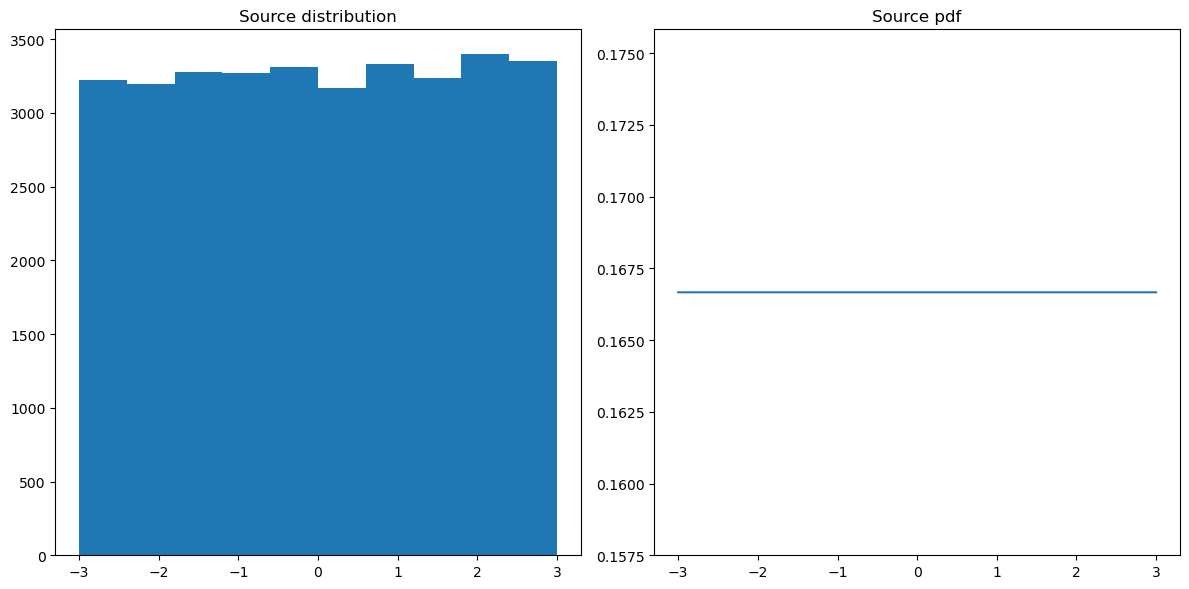

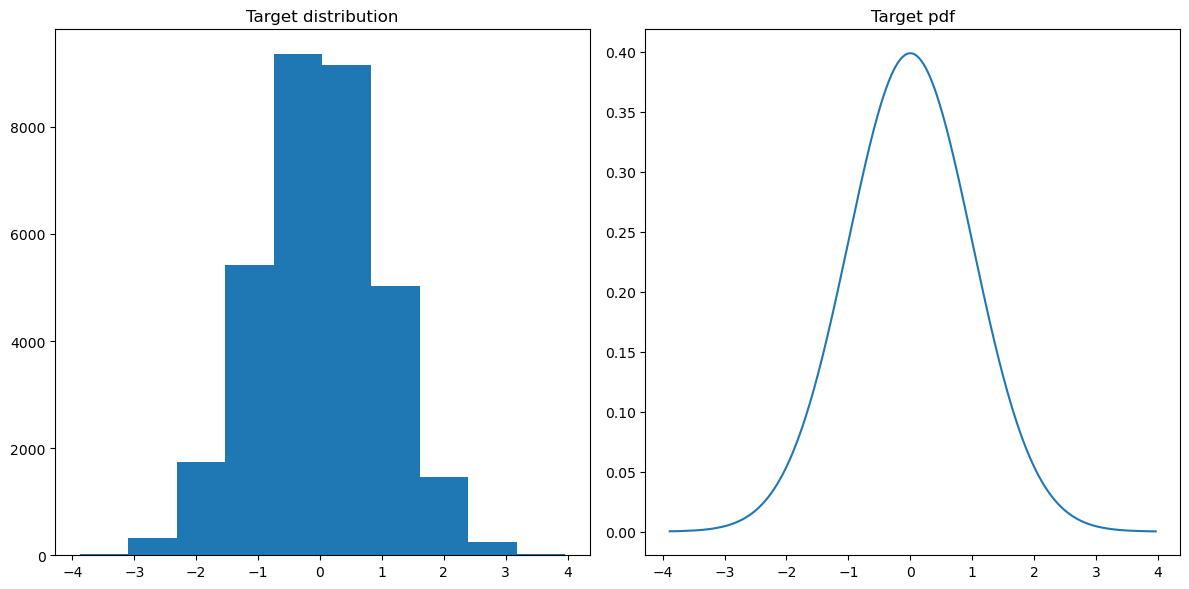

In [2]:
source_distr = lambda N: np.random.uniform(-3.0, 3.0, N)
source_distr_pdf = lambda x: (x >= -3.0) * (x <= 3.0) / 6.0

target_distr = lambda N: np.random.normal(0.0, 1.0, N)
target_distr_pdf = lambda x: np.exp(-0.5 * x ** 2) / np.sqrt(2.0 * np.pi)
target_unnormed_pdf = lambda x: np.exp(-0.5 * x ** 2)

N = 1 << 15
x = np.sort(source_distr(N))
x_pdf = source_distr_pdf(x)

y = np.sort(target_distr(N))
y_pdf = target_distr_pdf(y)

plt.figure(figsize=(12,6))
plt.subplot(121); plt.hist(x);          plt.title("Source distribution")
plt.subplot(122); plt.plot(x, x_pdf);   plt.title("Source pdf")
plt.tight_layout()

plt.figure(figsize=(12,6))
plt.subplot(121); plt.hist(y);          plt.title("Target distribution")
plt.subplot(122); plt.plot(y, y_pdf);   plt.title("Target pdf")
plt.tight_layout()



### Demo: resampled importance sampling

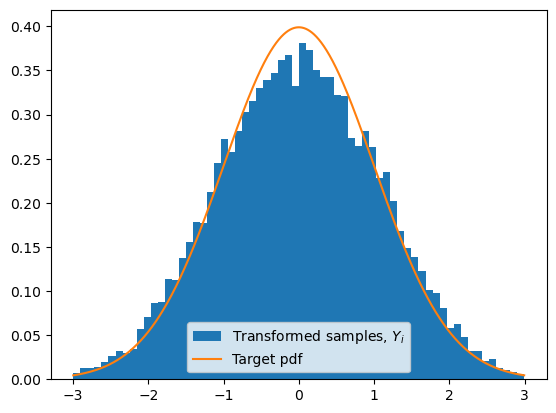

In [10]:
def sample_IR(M = 8):
    x_samples = source_distr(M)
    # note the use of the *unnormalized* target pdf!
    weights = target_unnormed_pdf(x_samples) / source_distr_pdf(x_samples)
    weights /= np.sum(weights)
    return np.random.choice(a=x_samples, p=weights, size=1).item()

N = 1 << 14
y_samples = np.zeros(N)
for i in range(N):
    y_samples[i] = sample_IR()

y_samples = np.sort(y_samples)
plt.hist(y_samples, bins=64, density=True, label=r"Transformed samples, $Y_{i}$")
plt.plot(y_samples, target_distr_pdf(y_samples), label="Target pdf")
plt.legend()

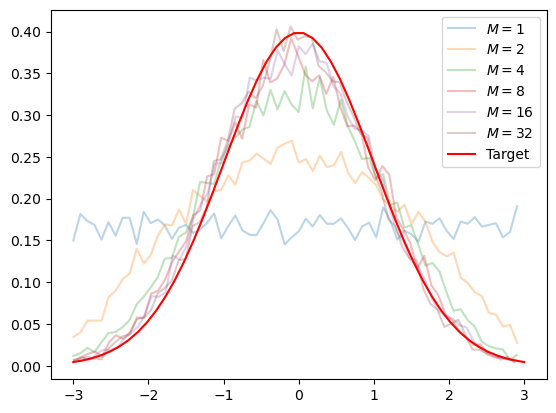

In [31]:
for M in [1,2,4,8,16,32]:
    y_samples = np.zeros(N)
    for i in range(N):
        y_samples[i] = sample_IR(M)
    ys, y_pdfs = np.histogram(y_samples, bins=64, density=True)
    plt.plot(y_pdfs[:-1], ys, alpha=0.3, label=r"$M=$"+f"{M}")
plt.plot(np.linspace(-3,3), target_distr_pdf(np.linspace(-3,3)), 'r-', label="Target")
plt.legend()

### Demo: reservoir sampling

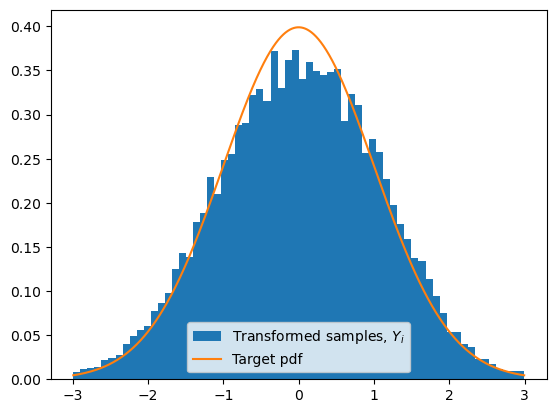

In [30]:
def sample_reservoir(M = 8, N = 1 << 14):
    sample_out = np.full(N, np.nan, dtype=np.float64)
    w_sums = np.zeros(N)

    for _ in range(M):
        # generate sample
        x_samples = source_distr(N)
        ws = target_unnormed_pdf(x_samples) / source_distr_pdf(x_samples)

        # decide whether to replace sample
        w_sums += ws
        rng = np.random.rand(N)
        mask = rng < ws / w_sums
        sample_out[mask] = x_samples[mask]
    return sample_out

y_samples = np.sort(sample_reservoir())
plt.hist(y_samples, bins=64, density=True, label=r"Transformed samples, $Y_{i}$")
plt.plot(y_samples, target_distr_pdf(y_samples), label="Target pdf")
plt.legend()

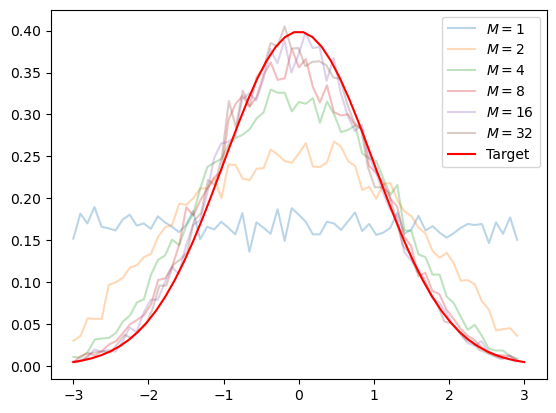

In [32]:
for M in [1,2,4,8,16,32]:
    y_samples = np.sort(sample_reservoir(M))
    ys, y_pdfs = np.histogram(y_samples, bins=64, density=True)
    plt.plot(y_pdfs[:-1], ys, alpha=0.3, label=r"$M=$"+f"{M}")
plt.plot(np.linspace(-3,3), target_distr_pdf(np.linspace(-3,3)), 'r-', label="Target")
plt.legend()
